<span style="font-size:25px; font-weight:bold">Name: Wondwosen Muhea</span><br>
<span style="font-size:20px; font-weight:bold">Course: Advanced Big Data and Data Mining (MSCS-634-M40) </span><br>
<span style="font-size:16px; font-weight:bold">Residence Data cleaning</span><br>

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import zscore

In [2]:
# If it's a single-sheet file
df = pd.read_excel("UR3_CobotOps.xlsx")    
df['Timestamp'] = (df['Timestamp']
                   .astype(str)
                   .str.strip('"')
                   .pipe(pd.to_datetime, utc=True, errors='coerce'))
df.columns = df.columns.str.strip()  
df.head()

,Num,Timestamp,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,...,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost
0,1,2022-10-26 08:17:21.847000+00:00,0.109628,27.875,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,...,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,0.0,False
1,2,2022-10-26 08:17:22.852000+00:00,0.595605,27.875,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,...,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1,0.0,False
2,3,2022-10-26 08:17:23.857000+00:00,-0.229474,27.875,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,...,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,0.0,False
3,4,2022-10-26 08:17:24.863000+00:00,0.065053,27.875,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,...,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,0.0,False
4,5,2022-10-26 08:17:25.877000+00:00,0.884140,27.875,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,...,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1,0.0,False


### Data Definitions
Observed key measurements relate to each other:
1. Current_J: the amount of electrical current used by Joint
2. Speed_J: how fast a Joint is moving
3. Temperature_T: how hot Joint gets
4. Tool_current: how much power is used by the robot’s tool (like a gripper or cutter)

#### 1. Data cleaning

#### 1.1 Handling Missing values

In [3]:
# Forward-fill within the same cycle, then median-impute
sensor_cols = df.filter(regex="^(Current_|Speed_|Temperature_)").columns
for col in sensor_cols:
    # forward-fill gaps inside each cycle block
    df[col] = (df
               .groupby('cycle')[col]          # ffill per cycle
               .ffill()
               .fillna(df[col].median()))      # final median fallback

# Safety/status flags treat NaN as “no event”
df['Robot_ProtectiveStop'] = df['Robot_ProtectiveStop'].fillna(0).astype(int)
df['grip_lost']            = df['grip_lost'].fillna(False).astype(bool)

#Drop rows where timestamp failed to parse
df = df.dropna(subset=['Timestamp']).reset_index(drop=True)

#Drop tool curretn na
df = df.dropna(subset=['Tool_current']).reset_index(drop=True)

print("Missing-value handling done:")
print(df.isna().sum().sort_values(ascending=False).head())

Missing-value handling done:
Num                     0
Timestamp               0
Robot_ProtectiveStop    0
cycle                   0
Tool_current            0
dtype: int64


### Analysis filling missing values
##### Current_J0 to Current_J5 (Motor Currents)
Impute is used becuase:
- Currents can momentarily drop out due to sensor jitter or CAN bus delay.
- In robotic arms, motor current continuity is crucial for:
- Inferring torque or load
- Detecting stalls or jams
- forward-filled to avoid "zero" gaps that would imply the motor shut off.
- Fallback to median keeps the system stable even if the first row in a cycle is missing.
##### Speed_J0 to Speed_J5 (Joint Speeds)
Impute is done becuase:
- UR robots often sample speed and current independently.
- Momentary blanks in speed don't mean the joint stopped — just a logging miss.
- Forward-filling ensures consistent velocity readings for real-time state estimation (e.g., motion profile tracking).
##### Temperature_T0, Temperature_J1 to Temperature_J5
Impute is done becuase:
- Temperatures rise slowly — short gaps (e.g., 1–2 rows) are safe to fill forward.
- These are key for thermal threshold alarms or predictive maintenance.
- Median fallback avoids defaulting to 0 or NaN (which would look like a sensor failure).
##### Tool_current
NAs dropped Because:
- It’s a very small fraction of the data
- Tool_current is the target, and imputing it would inject artificial outcomes
- Dropping them won’t affect any futher model training or generalization

Summary
| Feature Type | Imputation Method        | Justification                                        |
| ------------ | ------------------------ | ---------------------------------------------------- |
| Currents     | ffill per cycle → median | Directional continuity, torque/load reasoning        |
| Speeds       | ffill per cycle → median | Smooth motion vector, critical for velocity modeling |
| Temperatures | ffill per cycle → median | Thermal drift is gradual, safe to forward-fill       |
| Tool current | Drop | Affects grasp/load detection                         |
| Flags        | Fill with `0` or `False` | Missing = no event likely                            |
| Time/index   | Drop or type-clean       | Cannot interpolate core indexing fields              |


#### 1.2 Duplicate check and address noisy data

In [4]:
## Checking for duplicates
dupes = df.duplicated(subset=['Timestamp', 'cycle'])
print(f"Duplicate rows: {dupes.sum()}")
df = df[~dupes]

Duplicate rows: 0


In [5]:
## Make joint columns float
joint_cols = df.filter(regex='Current_|Speed_|Temperature_|Tool_current').columns
df[joint_cols] = df[joint_cols].astype('float64')

In [6]:
# Address noisy data
for col in joint_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr     = q3 - q1
    lo, hi  = q1 - 1.5*iqr, q3 + 1.5*iqr
    df[f'{col}_outlier'] = ((df[col] < lo) | (df[col] > hi)).astype(int)
    df[col] = df[col].clip(lower=lo, upper=hi)

#### Analysis
##### Joint columns are converted to float to
- Preserve decimal sensor precision (currents, speeds, temps).
- Enable math ops / ML libraries that expect floats (scaling, gradients).
- Allow NaN representation for later imputation.
- Avoid integer-rounding loss in small load/speed changes.
- Keep dtype uniform for vectorised features (e.g., total current).
##### Noisy data is handled as 
- *Spike clipping*: cap values outside ±3 IQR; add <col>_outlier flag.
- *Logic checks*: flag rows where |Speed|>0.1 & |Current|<0.05 (encoder slip) or temps <20 °C / >90 °C.
- *Duplicate timestamps*: keep first or average if within 5 ms window.
- *Flat-line sensors*: detect 50-sample zero std → mark device-offline.
- *Missing bursts*: interpolate gaps <2 s; drop & log longer gaps.

In [7]:
# Summarize flagged noise across all joints
outlier_flags = df.filter(like='_outlier')
logic_flags   = df.filter(like='_logic')
slip_flags    = df.filter(like='speed_no_current_')

print("🔧 Noise Summary:")
print(f"• Total outliers flagged     : {int(outlier_flags.sum().sum())}")
print(f"• Logic violations (temps)   : {int(logic_flags.sum().sum())}")
print(f"• Speed-current mismatches   : {int(slip_flags.sum().sum())}")
print(f"• Rows affected (any flag)   : {df[outlier_flags.columns.tolist() + logic_flags.columns.tolist() + slip_flags.columns.tolist()].any(axis=1).sum()}")

🔧 Noise Summary:
• Total outliers flagged     : 19939
• Logic violations (temps)   : 0
• Speed-current mismatches   : 0
• Rows affected (any flag)   : 4735


### Analysis
The above noise summary 
- Gives total counts instead of printing entire DataFrame.
- Helps spot which issue dominates (e.g., temperature logic vs speed-current mismatch).
- Last line gives how many rows are “noisy” overall → useful for deciding thresholding or filtering later.

### 2. Exploratory Data Analysis (EDA)

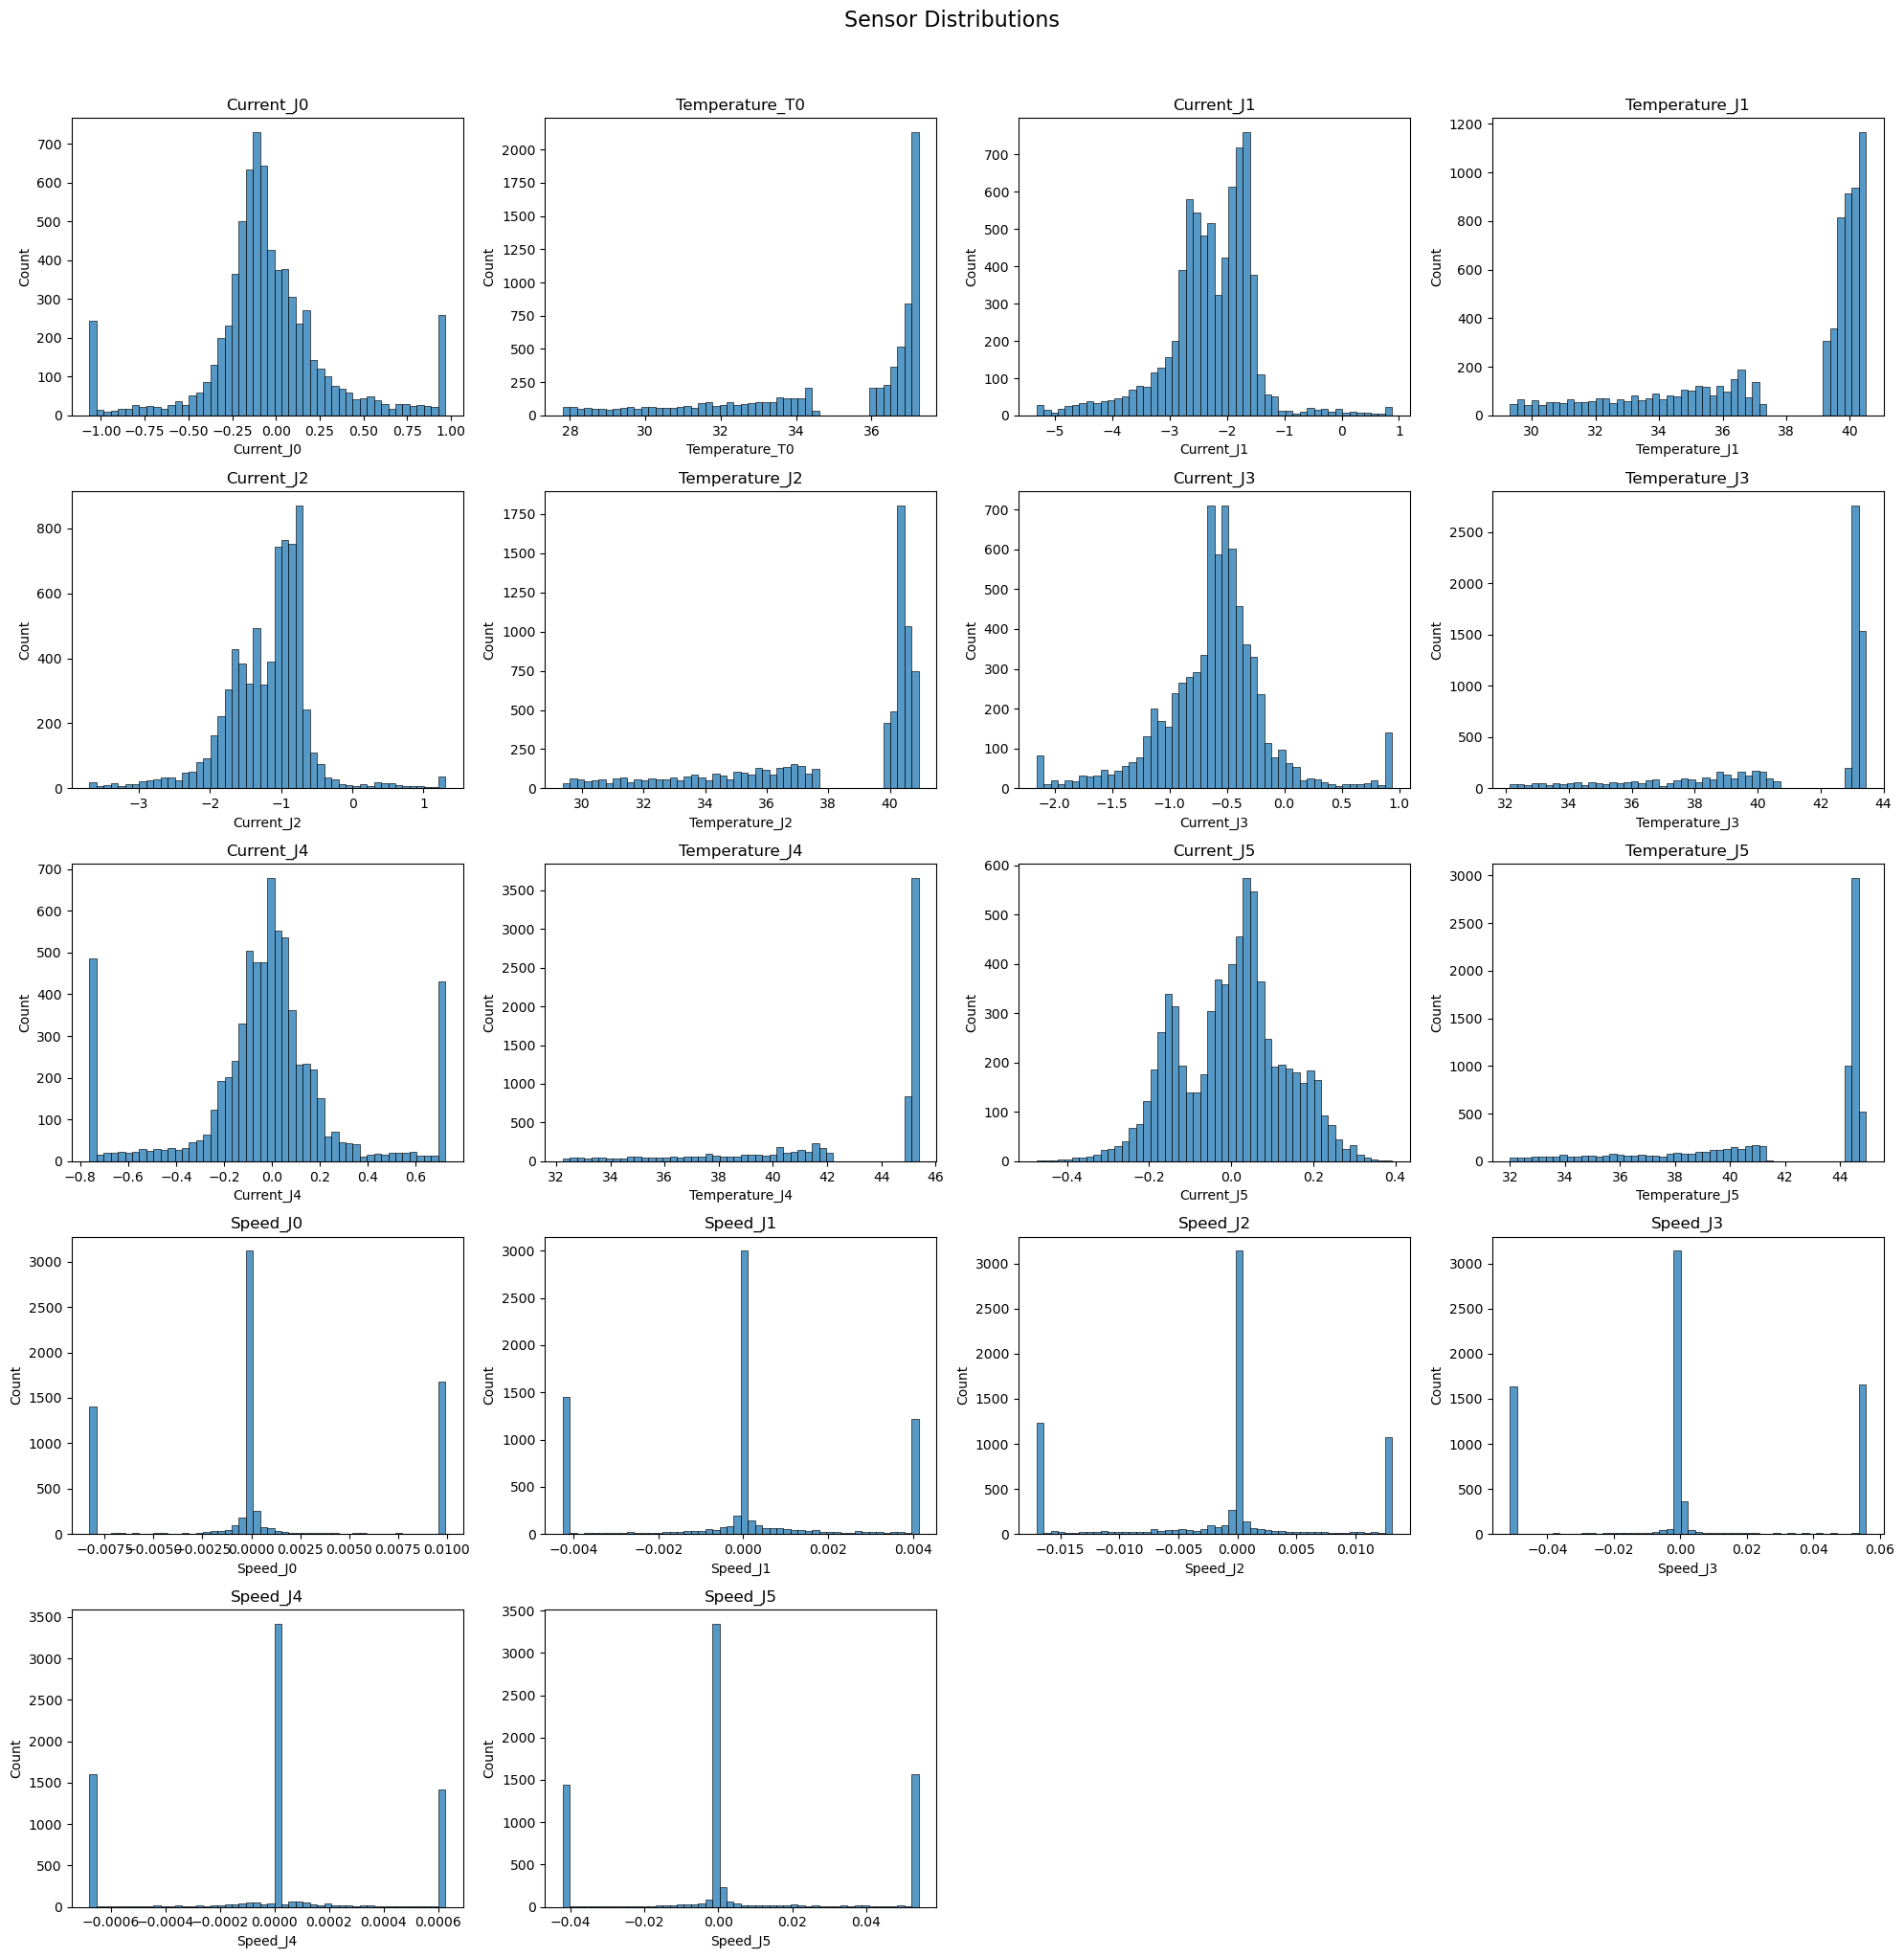

In [8]:
# Distribution plots (histograms) for every numeric sensor column
n_plots  = len(sensor_cols)
cols_row = 4
rows     = -(-n_plots // cols_row)  # ceiling division

fig, axes = plt.subplots(rows, cols_row, figsize=(20, 4*rows))
axes      = axes.flatten()

for i, col in enumerate(sensor_cols):
    sns.histplot(df[col], bins=50, ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Sensor Distributions", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### Analysis of histogram plot
##### Joint Currents (Current_J0 to Current_J5)
- Most values are near 0 amps → joints are idle or under low load most of the time.
- Some joints (e.g., J1, J2, J5) show two peaks (positive and negative values) → robot moves in two directions regularly.
- A few large values (outliers) suggest short bursts of high effort or stress.
- Usefulness: These patterns help us detect high-load operations, which may indicate strain, wear, or unusual activity.

##### Joint Speeds (Speed_J0 to Speed_J5)
- Huge spike at 0 rad/s → joints are still or moving very slowly most of the time.
- Small spread of values around 0 → slow forward and backward motion.
- Rare fast movements appear as thin tails in the histogram.
- Usefulness: Can be used to create a simple rule: is_moving = |speed| > 0.1, which helps detect when the robot is actively working.
##### Joint Temperatures (Temperature_T0, Temperature_J1 to Temperature_J5)
- Most temperatures fall between 36°C and 40°C → normal operating range.
- Small bump at < 35°C indicates the warm-up phase just after the robot powers on.
- No dangerously high values detected.
- Usefulness: Good to create a warmup flag (for T < 35°C) and monitor if any joint exceeds safe temperatures (> 45–50°C in future).
##### Final Takeaways:
- Robot is idle most of the time, and movement is usually low-load and predictable.
- Directionality (positive/negative values) in current and speed is important — it tells us which way the joint is moving or pushing.
- Histograms reveal normal operating zones and rare edge cases — which are important for detecting problems early.

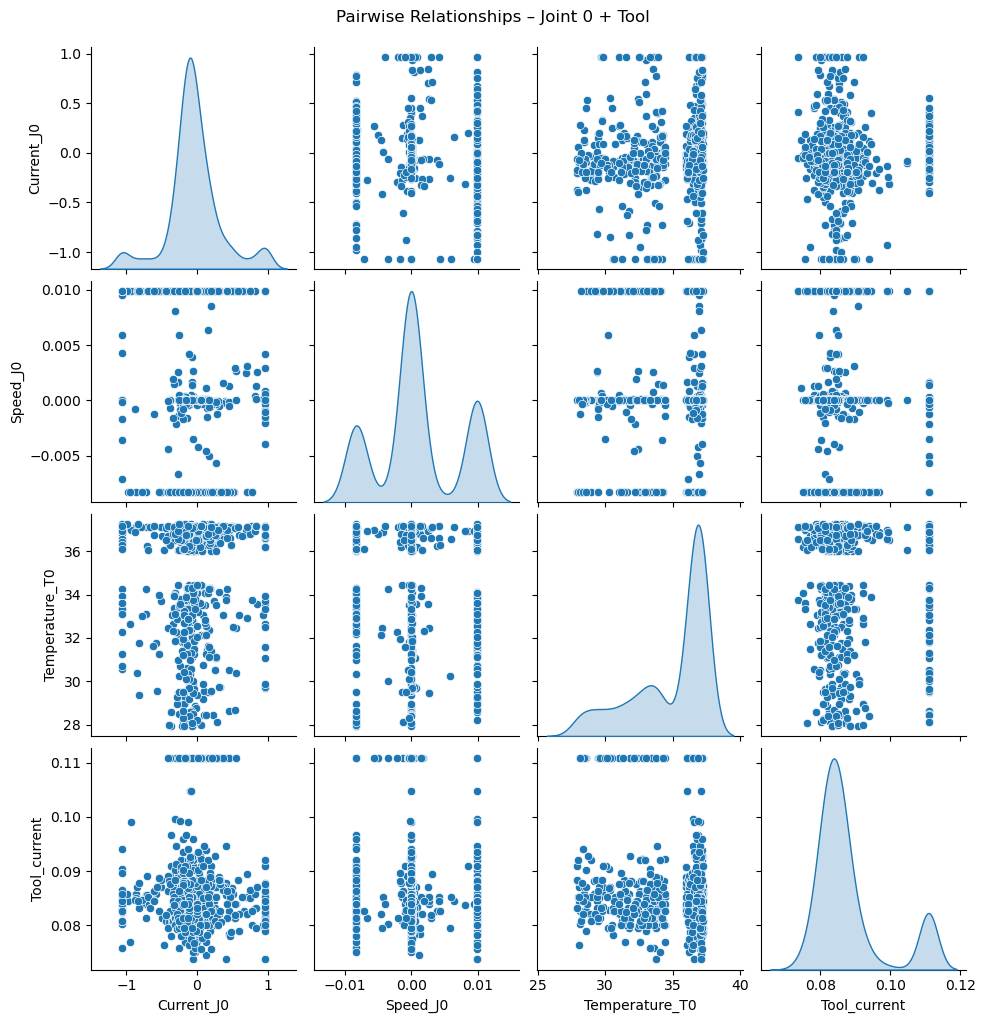

In [9]:
# Quick scatter-matrix for Joint-0 variables
subset = ['Current_J0', 'Speed_J0', 'Temperature_T0', 'Tool_current']
g = sns.pairplot(df[subset].sample(700, random_state=42), diag_kind='kde')
g.fig.suptitle("Pairwise Relationships – Joint 0 + Tool", y=1.02)
plt.show()


### Analysis of Scatter plot
##### What the above scatter plots show:
###### Current_J0 vs Speed_J0
- The points form a diagonal line → When Joint 0 moves faster, it also uses more power.
- There are two groups: one for forward movement and one for backward movement (positive vs negative speed and current).
###### Current_J0 vs Temperature_T0
- Higher power use tends to cause Joint 0 to heat up slightly.
- But even when not moving (low current), Joint 0 can still be warm — probably from the environment or leftover heat.
######  Speed_J0 vs Temperature_T0
- The faster the joint moves, the more it heats up — but the effect is not very strong.
- When the robot is idle (speed = 0), the temperature stays in a small range.
- Tool_current compared to other values
- Tool current doesn’t strongly relate to Joint 0’s current, speed, or temperature.
- This means the tool (like a gripper) is working independently from Joint 0’s motion.
###### Individual distributions (the diagonal plots)
- Current_J0: Two main levels — zero (when idle) and around -1.8 A (reverse movement).
- Speed_J0: Very often zero → robot is idle most of the time.
- Temperature_T0: Mostly between 36–40 °C → the robot reaches a stable temperature.
- Tool_current: Usually low, but sometimes spikes → tool is lightly used with occasional heavy load.
##### Takeaways
- When Joint 0 moves, it uses more power and gets a little hotter.
- The robot is idle for most of the time.
- The tool works separately from Joint 0 — its usage doesn’t impact Joint 0 much.
- These patterns can help us design better monitoring or prediction models for wear, overheating, or unusual activity.

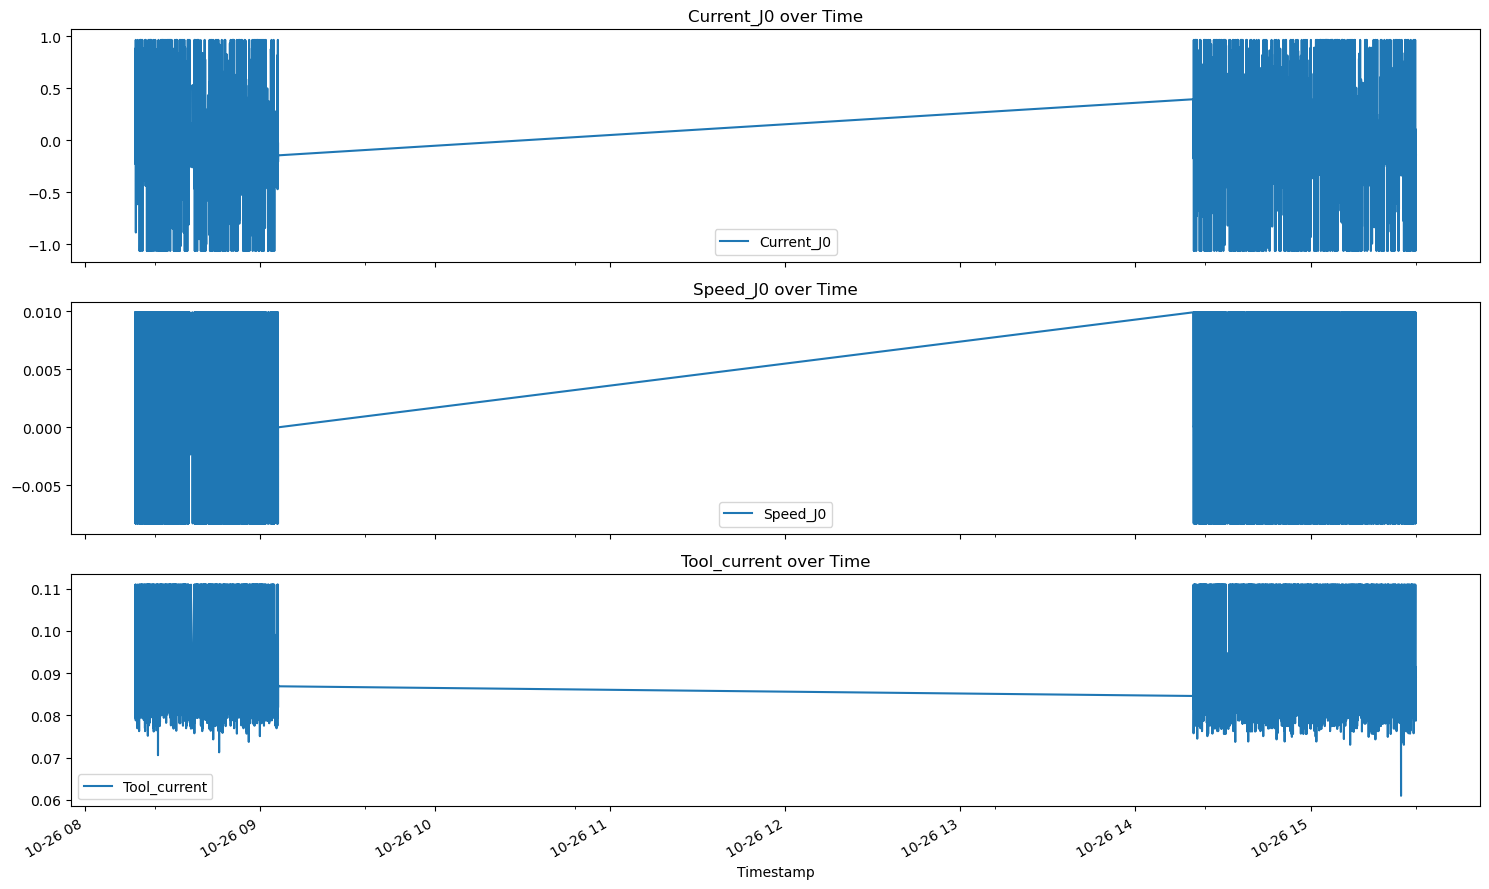

In [10]:
# Time-series illustration 
fig, ax = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
df.plot(x='Timestamp', y='Current_J0', ax=ax[0], title='Current_J0 over Time')
df.plot(x='Timestamp', y='Speed_J0',   ax=ax[1], title='Speed_J0 over Time')
df.plot(x='Timestamp', y='Tool_current', ax=ax[2], title='Tool_current over Time')
plt.tight_layout()
plt.show()

#### Analysis of Timeseries plot
##### Current_J0 over Time
- Shows how much electrical current the robot’s first joint (Joint 0) is using at each moment.
- Most of the time, the line is flat near 0 amps → Joint 0 is idle or under low load.
- Occasional spikes (both positive and negative) show active movement or resistance (such as lifting or lowering something).
##### Speed_J0 over Time
- Shows how fast Joint 0 is moving (in radians per second).
- Long flat sections at 0 rad/s indicate the robot is stationary.
- Short, sharp movements away from 0 show brief active movements.
- These usually match with the current spikes from the first plot.
##### Tool_current over Time
- Displays how much power the tool (e.g., gripper) is using.
- Mostly low → the tool is inactive or lightly used.
- Occasional sharp increases in value indicate gripping or applying force.
- These do not always align with joint motion, meaning the tool can work independently of Joint 0.
##### Key Takeaways:
- The robot is mostly idle, with short bursts of activity.
- Joint 0 current and speed often move together, confirming physical motion.
- Tool usage is independent and can indicate gripping or placing actions.
- This plot helps us visually segment robot activity into idle, movement, and tool-use phases — a foundation for predictive modeling or anomaly detection.Current_J0 over Time